CSE754 - PHASE 5: Cross-Batch Generalization Split (LIVECell)

# CSE754 - PHASE 5: Source-Stratified (Cross-Batch) Split for Generalization Testing

**Author:** Sadia Ruhama — MSc Proposal (CSE 754)

**Why this notebook exists, and one honest constraint up front.** Slide 31's
"Cross-platform split design" says splits should be constructed by **source
(microscope/lab/batch)**, not random shuffling, so that a reported
generalization gap reflects genuine domain shift. Phase 3/4 didn't do that --
Phase 3 sampled train/val/test images *randomly* within each cell type, so
train and held-out sets almost certainly share the same imaging batches, and
Phase 4's "generalization" numbers are same-source numbers, not the
cross-source numbers the proposal is actually about.

The two datasets the proposal names for a genuinely different *microscope*
(JUMP Cell Painting, Human Cell Atlas) aren't practically usable here: JUMP is
multiple terabytes (Phase 4's own notes already flagged this as impractical
for a Colab session), and Human Cell Atlas is transcriptomic/marker reference
data, not microscopy images this vision pipeline can consume. So a genuine
*multi-microscope* cross-platform test is not what this notebook builds --
say so plainly in your write-up rather than overstating it.

What this notebook builds instead is the practical, defensible thing
achievable right now: LIVECell's own filenames encode **well/plate IDs**
(e.g. `C7_1` in `A172_Phase_C7_1_02d16h00m_2.tif`) -- each well is a
genuinely separate imaging instance (different physical culture, same
microscope). Holding out *entire wells* for val/test that never appear in
train is a real instance of the "batch" axis Slide 31 explicitly names
(microscope/**lab/batch**), and gives you an honest generalization-gap number
today. True multi-microscope cross-platform testing remains future work --
this is the batch-level version of it.

**Output:** a second `ImageFolder`-style tree at
`cse754/data_crossbatch/{train,val,test}/<CellType>/*.png`, held out by well
ID rather than by randomly sampled image. Phase 4 v2's pipeline is reused
completely unchanged -- point its `DATA_DIR` at this new folder and rerun to
get the actual generalization-gap comparison against Phase 4 v2's original
(same-batch) run. No changes to the model/training code are needed.

**Recommended runtime:** Colab CPU is fine for this notebook (no model
training happens here, just downloading/cropping images) -- GPU not required.

## 1. Setup — installs and Google Drive

In [ ]:
!pip install -q -U pycocotools pillow requests tqdm

import os
import re
import json
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/cse754'
# Separate from Phase 3's cse754/data -- this is a DIFFERENT split
# (batch-stratified) of the SAME underlying LIVECell images, so it must not
# overwrite Phase 3's random-sampled split.
DATA_DIR = os.path.join(PROJECT_ROOT, 'data_crossbatch')
OUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
PHASE5_DIR = os.path.join(OUT_DIR, 'phase5')

# Raw LIVECell download stays on local Colab disk (ephemeral), same as
# Phase 3 -- it's intermediate data, not a deliverable, and re-downloading
# per session is fast (~1-2 min based on Phase 3's actual run).
RAW_DIR = '/content/livecell_raw'
IMAGES_DIR = os.path.join(RAW_DIR, 'images')
ANN_DIR = os.path.join(RAW_DIR, 'annotations')

for d in [PROJECT_ROOT, DATA_DIR, OUT_DIR, PHASE5_DIR, RAW_DIR, IMAGES_DIR, ANN_DIR]:
    os.makedirs(d, exist_ok=True)

print('Drive project root :', PROJECT_ROOT)
print('New split target   :', DATA_DIR)
print('Local raw-data dir :', RAW_DIR)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 665.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
Mounted at /content/drive
Drive project root : /content/drive/MyDrive/cse754
New split target   : /content/drive/MyDrive/cse754/data_crossbatch
Local raw-data dir : /content/livecell_raw


## 2. Config

In [ ]:
from dataclasses import dataclass, field
from typing import Tuple

@dataclass
class CrossBatchConfig:
    # ---- Download sources (same URLs Phase 3 already verified working) ----
    images_zip_url: str = ('http://livecell-dataset.s3.eu-central-1.amazonaws.com/'
                            'LIVECell_dataset_2021/images.zip')
    ann_urls: dict = field(default_factory=lambda: {
        'train': 'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_train.json',
        'val':   'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_val.json',
        'test':  'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_test.json',
    })

    cell_types: Tuple[str, ...] = ('A172', 'BT474', 'BV2', 'Huh7', 'MCF7', 'SHSY5Y', 'SkBr3', 'SKOV3')

    # ---- Crop extraction (same as Phase 3) ----
    crop_size: int = 224
    bbox_padding_frac: float = 0.25

    # ---- Batch (well) stratification ----
    # We POOL LIVECell's own train+val+test images together per cell type,
    # then re-split by WELL ID -- LIVECell's own train/val/test boundary is
    # irrelevant here; we're building our own source-stratified split on top
    # of the union of all images.
    train_batch_fraction: float = 0.70   # fraction of DISTINCT WELLS assigned to train
    val_batch_fraction: float = 0.15     # fraction of DISTINCT WELLS assigned to val (held out)
    # remaining wells (~0.15) go to test (held out) -- val and test wells are
    # disjoint from EACH OTHER too, not just from train.

    # ---- How many crops to build per split/class ----
    train_crops_per_common_class: int = 400
    val_crops_per_class: int = 80
    test_crops_per_class: int = 100

    rare_cell_type: str = 'BV2'
    train_crops_for_rare_class: int = 15   # matches Phase 3's constructed rarity

    max_images_scanned_per_well: int = 20  # cap source images drawn from any one well
    max_crops_per_source_image: int = 25

    seed: int = 42


cb_cfg = CrossBatchConfig()
print(cb_cfg)

CrossBatchConfig(images_zip_url='http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/images.zip', ann_urls={'train': 'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_train.json', 'val': 'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_val.json', 'test': 'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_test.json'}, cell_types=('A172', 'BT474', 'BV2', 'Huh7', 'MCF7', 'SHSY5Y', 'SkBr3', 'SKOV3'), crop_size=224, bbox_padding_frac=0.25, train_batch_fraction=0.7, val_batch_fraction=0.15, train_crops_per_common_class=400, val_crops_per_class=80, test_crops_per_class=100, rare_cell_type='BV2', train_crops_for_rare_class=15, max_images_scanned_per_well=20, max_crops_per_source_image=25, seed=42)


## 3. Download annotations and images.zip

Identical to Phase 3 -- same URLs, same ~1.3GB unzipped size. If you still
have `/content/livecell_raw` from a Phase 3 run **in the same Colab
session**, this cell detects that and skips re-downloading; if this is a
fresh session (the common case -- Colab's local disk doesn't persist between
sessions), it re-downloads, which took under 2 minutes in the Phase 3 run.

In [ ]:
import requests
from tqdm import tqdm
import zipfile

def download_file(url: str, dest_path: str, chunk_size: int = 1 << 20):
    if os.path.exists(dest_path) and os.path.getsize(dest_path) > 0:
        print(f'  already downloaded: {dest_path}')
        return
    resp = requests.get(url, stream=True, timeout=60)
    resp.raise_for_status()
    total = int(resp.headers.get('content-length', 0))
    with open(dest_path, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True, desc=os.path.basename(dest_path)) as pbar:
        for chunk in resp.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))

print('Downloading annotation JSONs...')
ann_paths = {}
for split, url in cb_cfg.ann_urls.items():
    dest = os.path.join(ANN_DIR, f'livecell_coco_{split}.json')
    download_file(url, dest)
    ann_paths[split] = dest

print('Downloading images.zip (~1.3GB unzipped)...')
zip_path = os.path.join(RAW_DIR, 'images.zip')
download_file(cb_cfg.images_zip_url, zip_path)

if not os.path.exists(os.path.join(IMAGES_DIR, 'livecell_train_val_images')):
    print('Unzipping images.zip...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(RAW_DIR)
    print('Done. Contents of', RAW_DIR, ':', os.listdir(RAW_DIR))
else:
    print('Already unzipped.')

livecell_coco_train.json: 100%|██████████| 551M/551M [00:38<00:00, 14.3MB/s]
livecell_coco_val.json: 100%|██████████| 97.3M/97.3M [00:06<00:00, 14.3MB/s]
livecell_coco_test.json: 100%|██████████| 261M/261M [00:17<00:00, 15.1MB/s]


images.zip: 100%|██████████| 1.24G/1.24G [01:03<00:00, 19.7MB/s]


Unzipping images.zip...
Done. Contents of /content/livecell_raw : ['annotations', 'images', 'images.zip']


## 4. Load COCO annotations, index files on disk, extract batch (well) IDs

Same flat-file indexing fix Phase 3 used (LIVECell's README implies
per-cell-type subfolders; the files are actually flat) -- we build a
filename -> path map once and look files up by name regardless of layout.
NEW: also parses each filename's **well ID** (e.g. `C7_1`), which is the
batch key this notebook splits on.

In [ ]:
from pycocotools.coco import COCO

def cell_type_from_filename(file_name: str) -> str:
    return file_name.split('_Phase_')[0]

# Matches e.g. 'A172_Phase_C7_1_02d16h00m_2.tif' -> well/plate id 'C7_1'.
# The pattern is <CellType>_Phase_<Well>_<Timepoint:NNdNNhNNm>_<FieldIndex>.tif
_WELL_ID_PATTERN = re.compile(r'^[A-Za-z0-9]+_Phase_([A-Za-z]+\d+_\d+)_\d+d\d+h\d+m_\d+\.tif$')

def well_id_from_filename(file_name: str) -> str:
    '''Returns the well/plate ID (a proxy for "imaging batch") parsed from a
    LIVECell filename. Falls back to the whole filename (minus extension) if
    the expected pattern doesn't match, so an unexpected filename still gets
    a (less precise but non-crashing) batch key instead of raising.'''
    m = _WELL_ID_PATTERN.match(file_name)
    if m:
        return m.group(1)
    return os.path.splitext(file_name)[0]


cocos = {split: COCO(path) for split, path in ann_paths.items()}

IMAGE_SUBDIR = {
    'train': 'livecell_train_val_images',
    'val': 'livecell_train_val_images',
    'test': 'livecell_test_images',
}

print('Indexing extracted image files (building filename -> path map)...')
FILENAME_INDEX = {}
for root, _, files in os.walk(IMAGES_DIR):
    for fn in files:
        if fn.lower().endswith('.tif'):
            FILENAME_INDEX[fn] = os.path.join(root, fn)
print(f'Indexed {len(FILENAME_INDEX):,} .tif files under {IMAGES_DIR}')
if len(FILENAME_INDEX) == 0:
    print('  [WARN] No .tif files found -- check Section 3 output before continuing.')

def resolve_image_path(file_name: str):
    return FILENAME_INDEX.get(file_name)

# Sanity check: confirm well-ID parsing on a few real filenames.
_sample_names = list(FILENAME_INDEX.keys())[:5]
print('\nWell-ID parsing sanity check:')
for name in _sample_names:
    print(f'  {name}  ->  cell_type={cell_type_from_filename(name):8s} well={well_id_from_filename(name)}')

loading annotations into memory...
Done (t=24.21s)
creating index...
index created!
loading annotations into memory...
Done (t=3.06s)
creating index...
index created!
loading annotations into memory...
Done (t=8.28s)
creating index...
index created!
Indexing extracted image files (building filename -> path map)...
Indexed 5,239 .tif files under /content/livecell_raw/images

Well-ID parsing sanity check:
  A172_Phase_C7_2_00d20h00m_2.tif  ->  cell_type=A172     well=C7_2
  Huh7_Phase_A12_2_01d08h00m_1.tif  ->  cell_type=Huh7     well=A12_2
  Huh7_Phase_A12_1_01d16h00m_4.tif  ->  cell_type=Huh7     well=A12_1
  A172_Phase_C7_2_02d16h00m_1.tif  ->  cell_type=A172     well=C7_2
  Huh7_Phase_A12_2_01d12h00m_4.tif  ->  cell_type=Huh7     well=A12_2


## 5. Pool all images per cell type and group by well ID

Unlike Phase 3 (which kept LIVECell's own train/val/test images separate),
we POOL every image LIVECell has for each cell type -- across all three of
LIVECell's own splits -- because we're building an entirely new split
ourselves, by well, not reusing LIVECell's split boundary.

In [ ]:
from collections import defaultdict

# image_id -> (split, file_name) for every image across all three COCO files,
# deduplicated by file_name (train_val_images are shared between LIVECell's
# 'train' and 'val' splits, so the same file can appear in more than one
# COCO file -- keep one record per unique file_name).
all_images_by_celltype = defaultdict(dict)   # cell_type -> {file_name: (split, img_id)}

for split, coco in cocos.items():
    for img_id in coco.getImgIds():
        info = coco.loadImgs(img_id)[0]
        fn = info['file_name']
        ctype = cell_type_from_filename(fn)
        if fn not in all_images_by_celltype[ctype]:
            all_images_by_celltype[ctype][fn] = (split, img_id)

for ctype, images in all_images_by_celltype.items():
    n_wells = len({well_id_from_filename(fn) for fn in images})
    print(f'{ctype:8s}: {len(images):5d} unique images pooled across {n_wells:3d} distinct wells')

BT474   :   672 unique images pooled across   8 distinct wells
A172    :   608 unique images pooled across   8 distinct wells
MCF7    :   735 unique images pooled across   8 distinct wells
BV2     :   608 unique images pooled across   8 distinct wells
Huh7    :   600 unique images pooled across   6 distinct wells
SkBr3   :   704 unique images pooled across   8 distinct wells
SKOV3   :   608 unique images pooled across   8 distinct wells
SHSY5Y  :   704 unique images pooled across   8 distinct wells


## 6. Split wells (not images) into train/val/test -- the actual cross-batch step

For each cell type: list its distinct well IDs, shuffle them (seeded), and
assign whole wells to train/val/test by `train_batch_fraction` /
`val_batch_fraction`. **No well appears in more than one split.** This is
the step that makes val/test genuine held-out batches rather than randomly
sampled images that likely share a well (and therefore share
lighting/focus/confluency conditions) with the training images.

In [ ]:
import numpy as np
rng = np.random.RandomState(cb_cfg.seed)

well_split_assignment = {}   # cell_type -> {well_id: 'train'|'val'|'test'}
images_by_split = defaultdict(lambda: defaultdict(list))  # split -> cell_type -> [file_name, ...]

for ctype, images in all_images_by_celltype.items():
    wells = sorted({well_id_from_filename(fn) for fn in images})
    rng.shuffle(wells)
    n_wells = len(wells)
    n_train = max(1, int(round(n_wells * cb_cfg.train_batch_fraction)))
    n_val = max(1, int(round(n_wells * cb_cfg.val_batch_fraction)))
    n_val = min(n_val, n_wells - n_train - 1) if n_wells - n_train > 1 else 0
    train_wells = set(wells[:n_train])
    val_wells = set(wells[n_train:n_train + n_val])
    test_wells = set(wells[n_train + n_val:])

    well_split_assignment[ctype] = {}
    for w in train_wells:
        well_split_assignment[ctype][w] = 'train'
    for w in val_wells:
        well_split_assignment[ctype][w] = 'val'
    for w in test_wells:
        well_split_assignment[ctype][w] = 'test'

    for fn in images:
        w = well_id_from_filename(fn)
        target_split = well_split_assignment[ctype][w]
        images_by_split[target_split][ctype].append(fn)

    print(f'{ctype:8s}: {n_wells:3d} wells -> train={len(train_wells):3d} wells '
          f'({sum(1 for fn in images if well_split_assignment[ctype][well_id_from_filename(fn)]=="train")} imgs) | '
          f'val={len(val_wells):3d} wells | test={len(test_wells):3d} wells')

BT474   :   8 wells -> train=  6 wells (504 imgs) | val=  1 wells | test=  1 wells
A172    :   8 wells -> train=  6 wells (456 imgs) | val=  1 wells | test=  1 wells
MCF7    :   8 wells -> train=  6 wells (551 imgs) | val=  1 wells | test=  1 wells
BV2     :   8 wells -> train=  6 wells (456 imgs) | val=  1 wells | test=  1 wells
Huh7    :   6 wells -> train=  4 wells (400 imgs) | val=  1 wells | test=  1 wells
SkBr3   :   8 wells -> train=  6 wells (528 imgs) | val=  1 wells | test=  1 wells
SKOV3   :   8 wells -> train=  6 wells (456 imgs) | val=  1 wells | test=  1 wells
SHSY5Y  :   8 wells -> train=  6 wells (528 imgs) | val=  1 wells | test=  1 wells


## 7. Crop single cells from bounding boxes and save as PNGs

Same ground-truth-bbox cropping logic as Phase 3 (LIVECell's real annotated
boundaries stand in for the proposal's SAM2 preprocessing step). The only
difference: which source images are eligible for each split is now
determined by Section 6's well assignment, not by LIVECell's own split or by
random image sampling.

In [ ]:
from PIL import Image

crop_rng = np.random.RandomState(cb_cfg.seed + 1)

# file_name -> (split, coco_split_key, img_id) so we can look up annotations
# regardless of which of LIVECell's own COCO files first listed the image.
file_lookup = {}
for ctype, images in all_images_by_celltype.items():
    for fn, (coco_split_key, img_id) in images.items():
        file_lookup[fn] = (coco_split_key, img_id)


def load_gray_as_rgb(path: str) -> Image.Image:
    img = Image.open(path)
    if img.mode != 'RGB':
        img = img.convert('L').convert('RGB')
    return img


def crop_one_cell(pil_img: Image.Image, bbox, cfg: CrossBatchConfig) -> Image.Image:
    x, y, w, h = bbox
    pad_x, pad_y = w * cfg.bbox_padding_frac, h * cfg.bbox_padding_frac
    left = max(0, int(x - pad_x))
    top = max(0, int(y - pad_y))
    right = min(pil_img.width, int(x + w + pad_x))
    bottom = min(pil_img.height, int(y + h + pad_y))
    if right <= left or bottom <= top:
        return None
    crop = pil_img.crop((left, top, right, bottom))
    side = max(crop.width, crop.height)
    square = Image.new('RGB', (side, side), (0, 0, 0))
    square.paste(crop, ((side - crop.width) // 2, (side - crop.height) // 2))
    return square.resize((cfg.crop_size, cfg.crop_size), Image.BILINEAR)


def build_crops_for_split(split: str, cfg: CrossBatchConfig, out_root: str):
    class_counts = {}
    for cell_type in cfg.cell_types:
        file_names = images_by_split[split].get(cell_type, [])
        if not file_names:
            print(f'  [WARN] no images assigned to {cell_type} in {split} split -- skipping')
            class_counts[cell_type] = 0
            continue

        if cell_type == cfg.rare_cell_type and split == 'train':
            target_crops = cfg.train_crops_for_rare_class
        elif split == 'train':
            target_crops = cfg.train_crops_per_common_class
        elif split == 'val':
            target_crops = cfg.val_crops_per_class
        else:
            target_crops = cfg.test_crops_per_class

        out_dir = os.path.join(out_root, split, cell_type)
        os.makedirs(out_dir, exist_ok=True)

        # Draw source images well-by-well (not globally shuffled) so crops
        # stay spread across the split's held-out wells rather than being
        # dominated by whichever well happens to sort first.
        by_well = defaultdict(list)
        for fn in file_names:
            by_well[well_id_from_filename(fn)].append(fn)
        well_ids = list(by_well.keys())
        crop_rng.shuffle(well_ids)

        saved = 0
        not_found = 0
        for w in well_ids:
            if saved >= target_crops:
                break
            fns = by_well[w][:cfg.max_images_scanned_per_well]
            crop_rng.shuffle(fns)
            for fn in fns:
                if saved >= target_crops:
                    break
                coco_split_key, img_id = file_lookup[fn]
                img_path = resolve_image_path(fn)
                if not img_path or not os.path.exists(img_path):
                    not_found += 1
                    continue
                pil_img = load_gray_as_rgb(img_path)

                coco = cocos[coco_split_key]
                ann_ids = coco.getAnnIds(imgIds=img_id)
                anns = coco.loadAnns(ann_ids)
                crop_rng.shuffle(anns)

                n_from_this_image = 0
                for ann in anns:
                    if saved >= target_crops or n_from_this_image >= cfg.max_crops_per_source_image:
                        break
                    crop = crop_one_cell(pil_img, ann['bbox'], cfg)
                    if crop is None:
                        continue
                    out_path = os.path.join(out_dir, f'{cell_type}_{split}_{saved:05d}.png')
                    crop.save(out_path)
                    saved += 1
                    n_from_this_image += 1

        class_counts[cell_type] = saved
        note = f' | {not_found} source images not found on disk' if not_found else ''
        print(f'  [{split}] {cell_type:8s}: saved {saved:4d} crops '
              f'(target {target_crops}, from {len(well_ids)} held-out wells){note}')
    return class_counts


all_class_counts = {}
for split in ['train', 'val', 'test']:
    print(f'--- Building crops for split: {split} (batch-stratified) ---')
    all_class_counts[split] = build_crops_for_split(split, cb_cfg, DATA_DIR)

--- Building crops for split: train (batch-stratified) ---
  [train] A172    : saved  400 crops (target 400, from 6 held-out wells)
  [train] BT474   : saved  400 crops (target 400, from 6 held-out wells)
  [train] BV2     : saved   15 crops (target 15, from 6 held-out wells)
  [train] Huh7    : saved  400 crops (target 400, from 4 held-out wells)
  [train] MCF7    : saved  400 crops (target 400, from 6 held-out wells)
  [train] SHSY5Y  : saved  400 crops (target 400, from 6 held-out wells)
  [train] SkBr3   : saved  400 crops (target 400, from 6 held-out wells)
  [train] SKOV3   : saved  400 crops (target 400, from 6 held-out wells)
--- Building crops for split: val (batch-stratified) ---
  [val] A172    : saved   80 crops (target 80, from 1 held-out wells)
  [val] BT474   : saved   80 crops (target 80, from 1 held-out wells)
  [val] BV2     : saved   80 crops (target 80, from 1 held-out wells)
  [val] Huh7    : saved   80 crops (target 80, from 1 held-out wells)
  [val] MCF7    : sav

## 8. Verify the resulting layout, report the class-index mapping, and save the well-split record

Same class-index mapping logic as Phase 3 -- and since the same 8 class
names are used, sorted order gives the **same mapping Phase 4 already uses**
(`rare_class_idx=2` for BV2), so no Config changes are needed on the training
side.

In [ ]:
train_classes_on_disk = sorted(os.listdir(os.path.join(DATA_DIR, 'train')))
class_to_idx = {c: i for i, c in enumerate(train_classes_on_disk)}
rare_class_idx = class_to_idx[cb_cfg.rare_cell_type]

print('Class -> index mapping (should match Phase 4\'s existing Config):')
for c, i in class_to_idx.items():
    print(f'  {i}: {c}')
print()
print('>>> Confirm in Phase 4 v2\'s Config (should already match): <<<')
print(f'    num_classes    = {len(class_to_idx)}')
print(f'    rare_class_idx = {rare_class_idx}   # ({cb_cfg.rare_cell_type})')

summary = {
    'class_to_idx': class_to_idx,
    'rare_class_idx': rare_class_idx,
    'rare_cell_type': cb_cfg.rare_cell_type,
    'counts_by_split': all_class_counts,
    'well_split_assignment': well_split_assignment,   # cell_type -> {well_id: split}
    'config': {k: v for k, v in cb_cfg.__dict__.items() if k not in ('ann_urls',)},
}
with open(os.path.join(PHASE5_DIR, 'crossbatch_split_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print('\nSaved split summary (including which wells went where) to',
      os.path.join(PHASE5_DIR, 'crossbatch_split_summary.json'))

Class -> index mapping (should match Phase 4's existing Config):
  0: A172
  1: BT474
  2: BV2
  3: Huh7
  4: MCF7
  5: SHSY5Y
  6: SKOV3
  7: SkBr3

>>> Confirm in Phase 4 v2's Config (should already match): <<<
    num_classes    = 8
    rare_class_idx = 2   # (BV2)

Saved split summary (including which wells went where) to /content/drive/MyDrive/cse754/outputs/phase5/crossbatch_split_summary.json


## 9. Sanity-check: no well leaks across splits (this is the whole point -- verify it)

If this assertion ever fails, the generalization-gap number downstream would
be meaningless (it would just be measuring within-batch noise again, exactly
the problem this notebook exists to avoid), so check it explicitly rather
than assuming Section 6's logic was correct.

In [ ]:
leak_found = False
for ctype in cb_cfg.cell_types:
    assignment = well_split_assignment.get(ctype, {})
    train_wells = {w for w, s in assignment.items() if s == 'train'}
    val_wells = {w for w, s in assignment.items() if s == 'val'}
    test_wells = {w for w, s in assignment.items() if s == 'test'}
    overlaps = (train_wells & val_wells) | (train_wells & test_wells) | (val_wells & test_wells)
    if overlaps:
        leak_found = True
        print(f'  [FAIL] {ctype}: wells appear in more than one split: {overlaps}')

if leak_found:
    raise AssertionError('Well leakage detected across splits -- see output above. '
                          'Do not proceed to training on this data until fixed.')
else:
    print('Sanity check passed: every well is assigned to exactly one split, for every cell type.')

Sanity check passed: every well is assigned to exactly one split, for every cell type.


## 10. Sanity-check: view a few crops per split

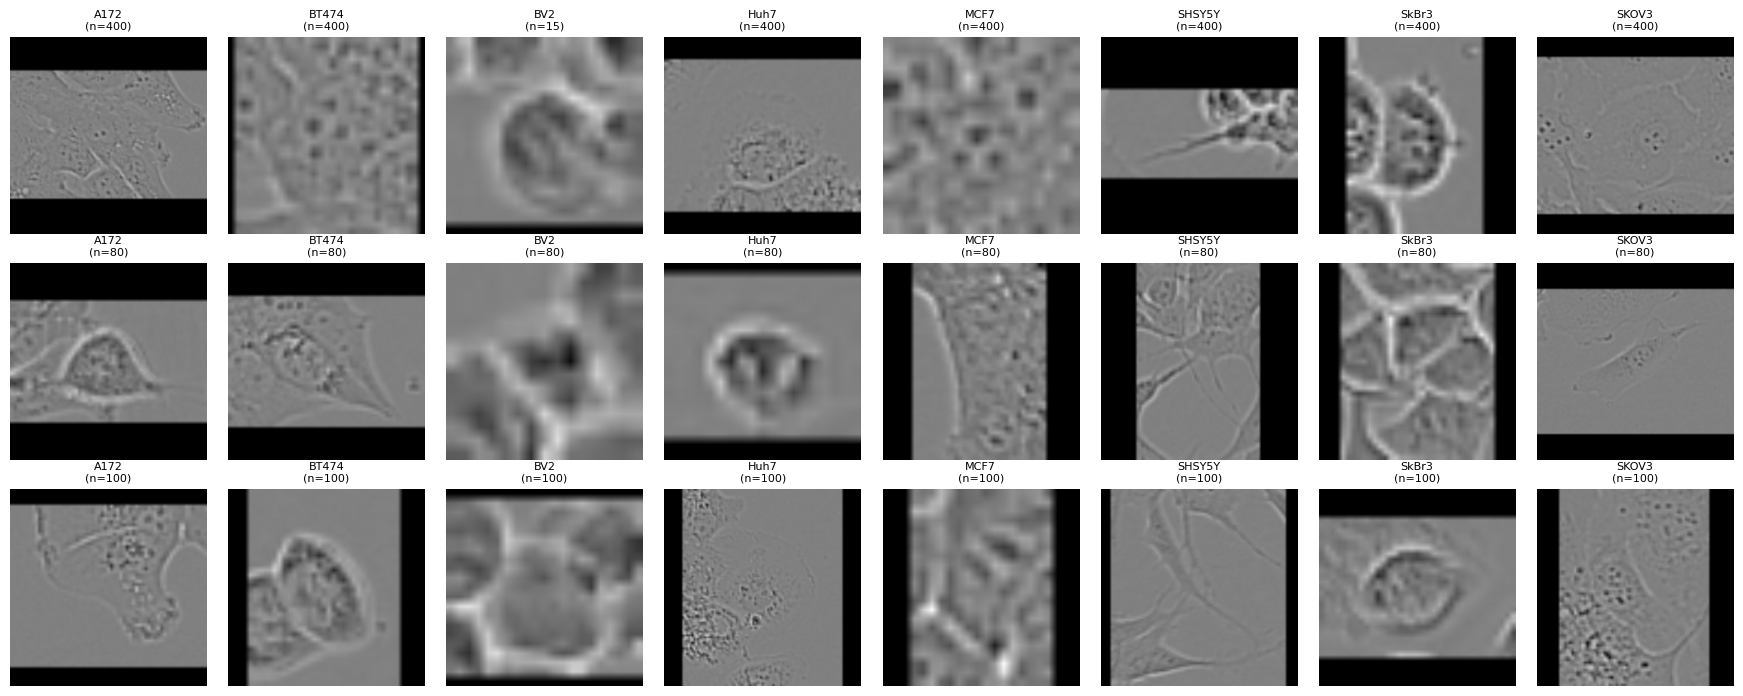

Saved sample grid to /content/drive/MyDrive/cse754/outputs/phase5/crossbatch_crop_samples.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, len(cb_cfg.cell_types), figsize=(2.2 * len(cb_cfg.cell_types), 7))
for row, split in enumerate(['train', 'val', 'test']):
    for col, cell_type in enumerate(cb_cfg.cell_types):
        class_dir = os.path.join(DATA_DIR, split, cell_type)
        files = os.listdir(class_dir) if os.path.isdir(class_dir) else []
        ax = axes[row, col]
        if files:
            img = Image.open(os.path.join(class_dir, files[0]))
            ax.imshow(img)
        ax.set_title(f'{cell_type}\n(n={len(files)})', fontsize=8)
        ax.axis('off')
    axes[row, 0].set_ylabel(split, fontsize=10)
plt.tight_layout()
plot_path = os.path.join(PHASE5_DIR, 'crossbatch_crop_samples.png')
plt.savefig(plot_path, dpi=130)
plt.show()
print('Saved sample grid to', plot_path)

## Notes / next steps

- **To actually measure the generalization gap**: take Phase 4 v2's script
  unchanged, and change exactly one line --
  `DATA_DIR = os.path.join(PROJECT_ROOT, 'data_crossbatch')` instead of
  `'data'` -- then rerun it top to bottom (also point its own output folder,
  e.g. `PHASE2_REAL_DIR`, at a new `phase2_crossbatch/` subfolder so it
  doesn't collide with the v1/v2 runs). Compare the resulting
  `al_results_log.json` test macro-F1 / rare-F1 / ECE against Phase 4 v2's
  same-batch run -- **the drop (if any) is the actual generalization-gap
  number** Slide 30 asks for.
- **If the gap is small**: that's a genuine, reportable finding too --
  it would suggest LIVECell's well-to-well variation isn't a strong source of
  domain shift for this backbone, which is useful to know and different from
  claiming "no cross-platform gap exists" (still an open question re: real
  multi-microscope shift).
- **State the scope honestly wherever this is reported**: this tests
  cross-*batch* (well-level) generalization within one imaging platform, not
  cross-*microscope* generalization (JUMP/HCA) -- both real per the
  proposal's Slide 31 framing, but not the same claim.